In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from marine_qc import (
    Climatology,
    do_bayesian_buddy_check,
)

In [4]:
from data import get_climatology_data, get_grouped_data

# How to use quality control checks with grouped reports

We need some text!!!

In [5]:
data = get_grouped_data()
data

,platform,date,lat,lon,sst
0,ship_1,2026-07-01 12:00:00,45.000914,-30.003120,19.612568
1,ship_1,2026-07-01 13:00:00,45.002822,-30.005853,23.977878
2,ship_1,2026-07-01 14:00:00,45.000384,-30.000949,19.670685
3,ship_1,2026-07-01 15:00:00,44.997441,-29.997362,19.616669
4,ship_1,2026-07-01 16:00:00,45.000198,-29.996618,19.396921
5,ship_1,2026-07-01 17:00:00,44.997422,-29.998894,19.182963
6,ship_2,2026-07-01 12:00:00,45.020635,-29.982150,19.472271
7,ship_2,2026-07-01 13:00:00,45.015957,-29.978332,19.650026
8,ship_2,2026-07-01 14:00:00,45.016715,-29.983056,24.253051
9,ship_2,2026-07-01 15:00:00,45.019096,-29.980762,19.564623


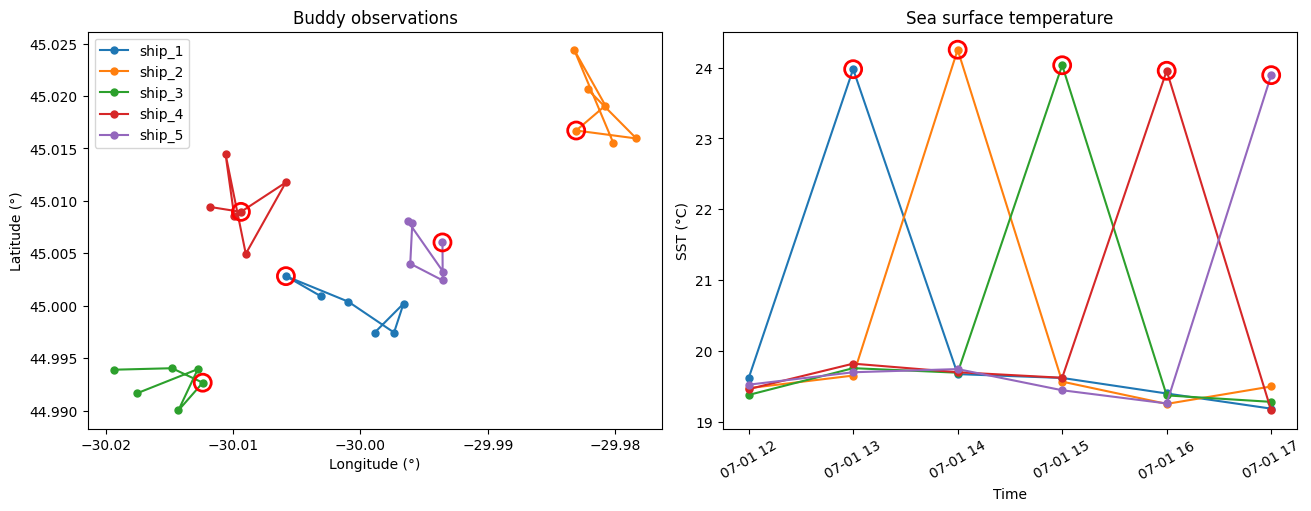

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

colors = plt.cm.tab10.colors

i = 0
for color, (platform, group) in zip(colors, data.groupby("platform"), strict=False):
    ax1.plot(
        group["lon"],
        group["lat"],
        "-o",
        ms=5,
        label=platform,
        color=color,
    )

    ax2.plot(
        group["date"],
        group["sst"],
        "-o",
        ms=5,
        label=platform,
        color=color,
    )

    outlier = data.loc[(data.platform == platform) & (data.date == pd.Timestamp(f"2026-07-01 {13 + i}:00"))]

    ax1.scatter(
        outlier.lon,
        outlier.lat,
        s=150,
        facecolors="none",
        edgecolors="red",
        linewidth=2,
        zorder=10,
    )

    ax2.scatter(
        outlier.date,
        outlier.sst,
        s=150,
        facecolors="none",
        edgecolors="red",
        linewidth=2,
        zorder=10,
    )

    i += 1

ax1.set_xlabel("Longitude (°)")
ax1.set_ylabel("Latitude (°)")
ax1.set_title("Buddy observations")
ax1.legend(loc="best")

ax2.set_xlabel("Time")
ax2.set_ylabel("SST (°C)")
ax2.set_title("Sea surface temperature")
ax2.tick_params(axis="x", rotation=30)

plt.show()

In [7]:
climatology_data = get_climatology_data()
climatology_data

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 1, latitude: 180, longitude: 360)
Coordinates:
  * time           (time) datetime64[us] 8B 2026-07-01T12:00:00
  * latitude       (latitude) int64 1kB -90 -89 -88 -87 -86 ... 85 86 87 88 89
  * longitude      (longitude) int64 3kB -180 -179 -178 -177 ... 176 177 178 179
Data variables:
    land_sea_mask  (time, latitude, longitude) int8 65kB 0 1 1 1 1 ... 0 0 0 0 0
    sst            (time, latitude, longitude) float64 518kB -1.225e-16 ... 0...
    sst_stdev1     (time, latitude, longitude) float64 518kB 0.475 ... 0.4754
    sst_stdev2     (time, latitude, longitude) float64 518kB 0.84 nan ... 0.8407
    sst_stdev3     (time, latitude, longitude) float64 518kB 0.235 ... 0.2352
    crs            int64 8B 0

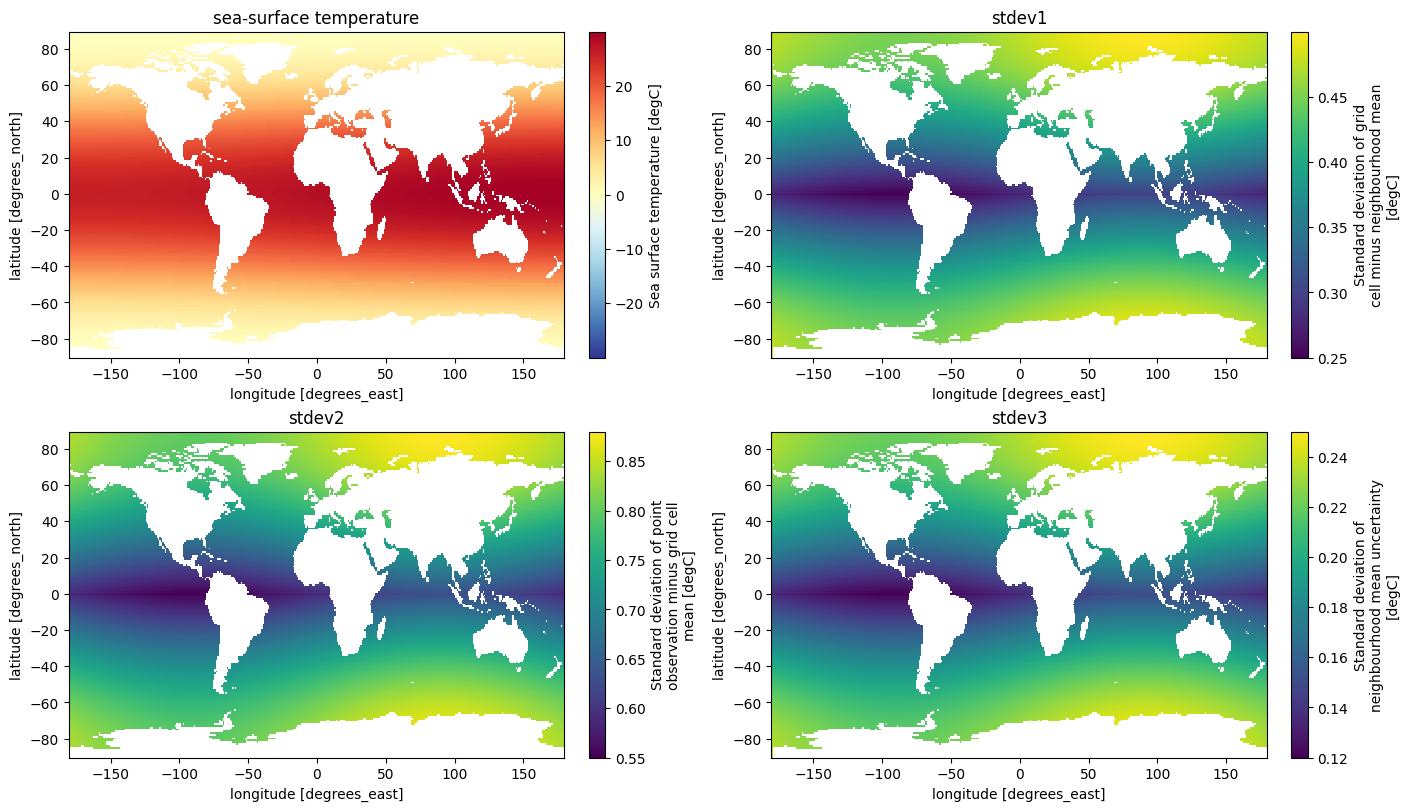

In [8]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8),
    constrained_layout=True,
)

plots = [
    ("sst", "sea-surface temperature", "RdYlBu_r"),
    ("sst_stdev1", "stdev1", "viridis"),
    ("sst_stdev2", "stdev2", "viridis"),
    ("sst_stdev3", "stdev3", "viridis"),
]

for ax, (var, title, cmap) in zip(axes.flat, plots, strict=False):
    climatology_data[var].isel(time=0).plot(
        ax=ax,
        cmap=cmap,
        add_colorbar=True,
    )
    ax.set_title(title)

plt.show()

In [9]:
sst_stdev1 = Climatology(climatology_data.sst_stdev1)
sst_stdev2 = Climatology(climatology_data.sst_stdev2)
sst_stdev3 = Climatology(climatology_data.sst_stdev3)

In [10]:
qc_buddy = do_bayesian_buddy_check(
    value=data.sst,
    lat=data.lat,
    lon=data.lon,
    date=data.date,
    climatology=climatology_data.sst,
    stdev1=sst_stdev1,
    stdev2=sst_stdev2,
    stdev3=sst_stdev3,
    prior_probability_of_gross_error=0.05,
    quantization_interval=0.1,
    one_sigma_measurement_uncertainty=1.0,
    limits=[2, 2, 4],
    noise_scaling=3.0,
    maximum_anomaly=8.0,
    fail_probability=0.3,
)
pd.DataFrame({**data, "qc_flag": qc_buddy})

,platform,date,lat,lon,sst,qc_flag
0,ship_1,2026-07-01 12:00:00,45.000914,-30.003120,19.612568,0
1,ship_1,2026-07-01 13:00:00,45.002822,-30.005853,23.977878,1
2,ship_1,2026-07-01 14:00:00,45.000384,-30.000949,19.670685,0
3,ship_1,2026-07-01 15:00:00,44.997441,-29.997362,19.616669,0
4,ship_1,2026-07-01 16:00:00,45.000198,-29.996618,19.396921,0
5,ship_1,2026-07-01 17:00:00,44.997422,-29.998894,19.182963,0
6,ship_2,2026-07-01 12:00:00,45.020635,-29.982150,19.472271,0
7,ship_2,2026-07-01 13:00:00,45.015957,-29.978332,19.650026,0
8,ship_2,2026-07-01 14:00:00,45.016715,-29.983056,24.253051,1
9,ship_2,2026-07-01 15:00:00,45.019096,-29.980762,19.564623,0
